In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))
import torch
import src
import matplotlib.pyplot as plt
from src.utils.utils import set_seed
import src.data.catalog as catalog
import src.catalogs as catalogs
import matplotlib.pyplot as plt
import numpy as np 
set_seed(0) 
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [2]:
from src.models.builders import ModelBuilder
from src.train.config_setup import load_args_from_checkpoint,load_model_from_checkpoint
checkpoint_dir = Path("../checkpoints/clf_mixer_attnpl_t_20260124-231641") 
checkpoint_path = checkpoint_dir / "best_model_1.pth"
check_point = torch.load(checkpoint_path,weights_only=False)
args = load_args_from_checkpoint(None, check_point)
model_builder = ModelBuilder.by_name(args.model.lower())()
model = model_builder(args, device)
model,_,_ = load_model_from_checkpoint(model, check_point)
model = torch.compile(model)
model.eval() 

FileNotFoundError: [Errno 2] No such file or directory: '../checkpoints/clf_mixer_attnpl_t_20260124-231641/best_model_1.pth'

In [ ]:
model.eval()
model.extractor.g

Parameter containing:
tensor([0.0385, 0.0565, 0.0431, 0.0216], device='cuda:0', requires_grad=True)

In [ ]:
from src.data.preparation import prepare_data
base_dir = f"../data/{args.dataset}"
df, train_loader, val_loader, test_loader, catalog_ds = prepare_data(base_dir=base_dir, args=args,)

CSV files found: ['Chuandian2021.csv']
Catalog statistics: {'tau_unfiltered': 0.15339908988298961, 'tau_q025': 0.08114294020924717, 'tau_q05': 0.5134664350189269, 'tau_mean': 1.3070542199341526, 'tau_max': 25.18216435192153, 'tau_min': 0.0, 'time_max': 18770.72654999979, 'time_mean': 10030.9430649837, 'mag_completeness': 3.0, 'mag_mean': 3.456916005014626, 'mag_max': 8.0, 'mag_min': 3.0, 'b_value': 0.856738547623331, 'b_std': 0.0071499224812533796, 'b_n': 14358}
stas {'tau_unfiltered': 0.15339908988298961, 'tau_q025': 0.08114294020924717, 'tau_q05': 0.5134664350189269, 'tau_mean': 1.3070542199341526, 'tau_max': 25.18216435192153, 'tau_min': 0.0, 'time_max': 18770.72654999979, 'time_mean': 10030.9430649837, 'mag_completeness': 3.0, 'mag_mean': 3.456916005014626, 'mag_max': 8.0, 'mag_min': 3.0, 'b_value': 0.856738547623331, 'b_std': 0.0071499224812533796, 'b_n': 14358}
[✔] Loading cached data from: ../data/ChuanDian/processed/classifier/classifier_Mc_3_Mf_4.5_Tfore_30_Twindow_180_context

In [ ]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu") 

In [ ]:
import src.data.event_loader as loader
args.batch_size =32
data_loader = loader.get_dataloader(catalog_ds, batch_size=args.batch_size, shuffle=False, task_type=args.task_type)

Positive samples: 836, Negative samples: 594
Total samples: 1430, Positive ratio: 0.58, Negative ratio: 0.42


In [ ]:
for x, y in val_loader:
    x, y = x.to(device), y.to(device)
    break

In [ ]:
model.base_model.input_adapter(x)['features'][0,:,0]

tensor([-0.4343, -0.0059, -0.4343, -0.0916, -0.4343, -0.2629, -0.0059, -0.3486,
        -0.4343, -0.4343, -0.4343,  0.5081, -0.2629,  0.1654, -0.0916,  0.5081,
        -0.4343, -0.0916,  0.3368, -0.0916, -0.0916,  0.4224, -0.2629, -0.1773,
        -0.1773, -0.3486, -0.3486, -0.3486,  0.2511,  0.1654, -0.4343, -0.4343,
        -0.1773, -0.0059, -0.0059,  0.1654, -0.0916, -0.4343,  0.8508,  0.0797,
         0.1654,  0.1654, -0.4343, -0.4343, -0.0059, -0.0059, -0.4343, -0.4343,
         0.5938, -0.2629, -0.4343, -0.4343, -0.0916, -0.2629,  0.4224, -0.3486,
        -0.3486, -0.4343,  0.3368, -0.3486, -0.4343, -0.2629, -0.3486, -0.4343,
        -0.0916,  0.8508, -0.1773, -0.4343, -0.2629, -0.1773,  0.1654,  0.3368,
        -0.4343,  0.5938,  0.2511, -0.1773, -0.0916, -0.4343, -0.0916, -0.3486,
        -0.0059,  0.4224, -0.3486, -0.1773,  1.6219, -0.0916,  0.2511, -0.2629,
        -0.0059, -0.4343, -0.1773,  0.8508, -0.1773,  0.0797,  0.1654, -0.1773,
        -0.0059, -0.0059,  0.1654,  0.67

In [ ]:
# x[0, :, 1]*args.Twindow/1.3
# model.base_model.input_adapter(x)['times']

tensor([[  0.3689,   3.7556,   9.0622,  ...,   0.0000,   0.0000,   0.0000],
        [  0.3386,   1.3211,   1.3282,  ...,   0.0000,   0.0000,   0.0000],
        [  0.9827,   1.3921,   2.4944,  ...,   0.0000,   0.0000,   0.0000],
        ...,
        [  0.6234,   1.6262,   2.2908,  ...,   0.0000,   0.0000,   0.0000],
        [  0.2797,   0.6318,   0.6400,  ...,   0.0000,   0.0000,   0.0000],
        [  2.3989,   3.5424,   5.3308,  ..., 136.0354, 136.0806, 137.5743]],
       device='cuda:0')

In [ ]:
model.eval()
model.extractor.t_mlp.to(device)
x = torch.linspace(0, 1, 100).unsqueeze(1)  
x = x.to(device)  
gamma, beta = model.extractor.t_mlp(x).chunk(2, dim=-1)  

In [ ]:
def predict_all(model, data_loader, device):
    y_pred_list = []
    y_list = []
    model.eval()  # Ensure the model is in evaluation mode
    with torch.no_grad():  # Disable gradient computation for inference
        for x, y in data_loader:
            x, y = x.to(device), y.to(device)
            y_pred = model(x)
            y_pred_list.append(y_pred.detach().cpu())
            y_list.append(y.detach().cpu())

    y_pred_all = torch.cat(y_pred_list, dim=0).numpy()
    y_all = torch.cat(y_list, dim=0).numpy()
    return y_pred_all, y_all


: 

In [ ]:
from src.utils.metrics import classification_metrics, log_metrics, plot_and_save_roc_curve, plot_classification_distribution
y_pred_all, y_all = predict_all(model,val_loader, device)
start=0
end =400
classification_metrics(y_all[start:end], y_pred_all[start:end])  

/root/miniconda3/lib/python3.12/site-packages/torch/_inductor/compile_fx.py:167: UserWarning: TensorFloat32 tensor cores for float32 matrix multiplication available but not enabled. Consider setting `torch.set_float32_matmul_precision('high')` for better performance.
  warnings.warn(


In [ ]:
# plt.plot(y_pred_all)
y_pred_all_nl = (y_pred_all - y_pred_all.min()) / (y_pred_all.max() - y_pred_all.min())

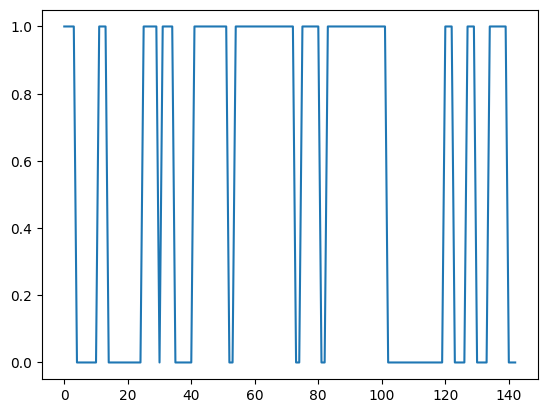

In [ ]:
plt.plot(y_all,)
# plt.plot(y_pred_all_nl>0.5)
# plt.plot(y_pred_all_nl)

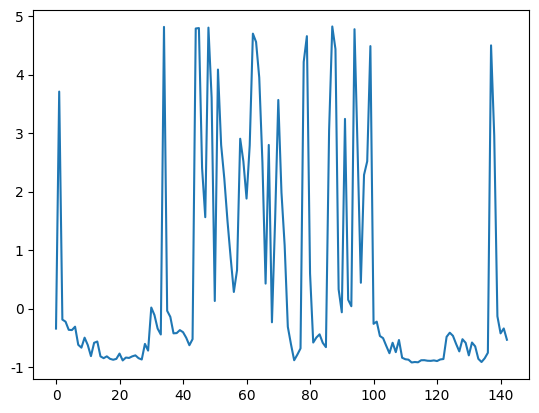

In [ ]:
plt.plot(y_pred_all)